# Inverse PINN for 1D linear elastostatics with batching

The goal is to identify both the displacement $u(x)$ and the unknown constant Young's modulus $E>0$ of a one-dimensional elastic bar on

$$
\Omega=(0,1).
$$

For a synthetic inverse experiment, the exact displacement is

$$
u_{\mathrm{exact}}(x)=a\sin(2\pi x),\qquad 0<a<\frac{1}{2\pi}.
$$

The strain and stress are

$$
\varepsilon(x)=u'(x),\qquad \sigma(x)=E u'(x),
$$

and equilibrium requires

$$
\left(Eu''(x)\right)+b(x)=0.
$$

A value $E_{\mathrm{true}}$ is used only once to generate the fixed known body force

$$
b_{\mathrm{known}}(x)=4\pi^2E_{\mathrm{true}}a\sin(2\pi x).
$$

The PINN learns its own value $E_\theta$ directly from the PDE and sparse displacement observations.


## 1. Library imports


In [77]:
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_default_dtype(torch.float64)


## 2. Parameters

Set `USE_NOISY_DATA = False` to use exact sparse observations. Set it to `True` to add independent zero-mean Gaussian measurement noise:

$$
u_i^{\mathrm{obs}}=u_{\mathrm{exact}}(x_i)+\eta_i,\qquad \eta_i\sim\mathcal N(0,s_{\mathrm{noise}}^2).
$$


In [78]:
USE_NOISY_DATA = True
NOISE_RELATIVE_STD = 0.02

L = 1.0
E_TRUE = 1.0
E_INITIAL = 30.0
AMPLITUDE = 0.05

N_PDE_TRAIN = 1000
N_PDE_VALIDATION = 100
N_PDE_TEST = 1000
PDE_BATCH_SIZE = 16
N_DATA_TOTAL = 26
N_DATA_TRAIN = 18
N_DATA_VALIDATION = 4
N_DATA_TEST = N_DATA_TOTAL - N_DATA_TRAIN - N_DATA_VALIDATION

EPOCHS = 2000
LBFGS_EPOCHS = 100
LR = 1e-3
SEED = 42

WEIGHT_PDE = 1.0
WEIGHT_DATA = 1000.0
WEIGHT_VALIDATION_PDE = WEIGHT_PDE
WEIGHT_VALIDATION_DATA = WEIGHT_DATA

NOISE_STD = NOISE_RELATIVE_STD * AMPLITUDE

torch.manual_seed(SEED)



## 3. Exact solution and fixed known loading

In [79]:
def exact_solution(x):
    """Exact displacement used to generate synthetic observations."""
    return AMPLITUDE * torch.sin(2.0 * torch.pi * x)


def exact_strain(x):
    """Exact strain u'(x)."""
    return 2.0 * torch.pi * AMPLITUDE * torch.cos(2.0 * torch.pi * x)


def exact_stress(x):
    """Exact stress generated with the true modulus."""
    return E_TRUE * exact_strain(x)


def known_body_force(x):
    """Fixed known body force."""
    return (4.0 * torch.pi**2 * E_TRUE * AMPLITUDE * torch.sin(2.0 * torch.pi * x))


## 4. Neural network and directly trainable Young's modulus

The network predicts $u_\theta(x)$. Young's modulus itself is stored directly as an `nn.Parameter`:

$$
E_\theta=\texttt{model.E}.
$$

No positivity transformation, clipping, or additional constraint is applied to $E_\theta$. The experiment therefore shows whether unconstrained optimization keeps the identified modulus physically admissible.


In [80]:
class InversePINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 10),
            nn.Tanh(),
            nn.Linear(10, 10),
            nn.Tanh(),
            nn.Linear(10, 10),
            nn.Tanh(),
            nn.Linear(10, 1),
        )

        self.E = nn.Parameter(torch.tensor(E_INITIAL))

    def forward(self, x):
        return self.net(x)

    def young_modulus(self):
        return self.E


model = InversePINN()
optimizer_adam = torch.optim.Adam(model.parameters(), lr=LR)


## 5. Training, validation, and test collocation points

Training collocation points are used by the optimizers. A separate fixed set of 1000 validation collocation points contributes only to checkpoint selection. Independent test points remain unused until the final evaluation.


In [81]:
pde_train_generator = torch.Generator().manual_seed(SEED + 1)
x_pde_train = L * torch.rand(N_PDE_TRAIN, 1, generator=pde_train_generator)
pde_dataset = TensorDataset(x_pde_train)
pde_batch_generator = torch.Generator().manual_seed(SEED + 2)
pde_loader = DataLoader(pde_dataset, batch_size=PDE_BATCH_SIZE, shuffle=True, generator=pde_batch_generator)

pde_validation_generator = torch.Generator().manual_seed(SEED + 3)
x_pde_validation = L * torch.rand(N_PDE_VALIDATION, 1, generator=pde_validation_generator)
x_pde_validation, _ = torch.sort(x_pde_validation, dim=0)

pde_test_generator = torch.Generator().manual_seed(SEED + 4)
x_pde_test = L * torch.rand(N_PDE_TEST, 1, generator=pde_test_generator)
x_pde_test, _ = torch.sort(x_pde_test, dim=0)


## 6. Train/validation/test split of sparse displacement observations

Only training observations update the network parameters. Validation observations contribute to the checkpoint score, and test observations remain unused until the final evaluation.


In [82]:
x_data_all = torch.linspace(0.0, L, N_DATA_TOTAL).view(-1, 1)
split_generator = torch.Generator().manual_seed(SEED + 6)
permutation = torch.randperm(N_DATA_TOTAL, generator=split_generator)
train_end = N_DATA_TRAIN
validation_end = N_DATA_TRAIN + N_DATA_VALIDATION
train_indices = permutation[:train_end]
validation_indices = permutation[train_end:validation_end]
test_indices = permutation[validation_end:]

u_data_all_clean = exact_solution(x_data_all).detach()
u_data_all_observed = u_data_all_clean.clone()
if USE_NOISY_DATA:
    noise_generator = torch.Generator().manual_seed(SEED + 7)
    u_data_all_observed += NOISE_STD * torch.randn(u_data_all_observed.shape, generator=noise_generator)

x_data_train = x_data_all[train_indices]
u_data_train = u_data_all_observed[train_indices]
u_data_train_clean = u_data_all_clean[train_indices]
x_data_validation = x_data_all[validation_indices]
u_data_validation = u_data_all_observed[validation_indices]
u_data_validation_clean = u_data_all_clean[validation_indices]
x_data_test = x_data_all[test_indices]
u_data_test = u_data_all_observed[test_indices]
u_data_test_clean = u_data_all_clean[test_indices]
print(f'Sparse data split: {N_DATA_TRAIN} train, {N_DATA_VALIDATION} validation, {N_DATA_TEST} test')


Sparse data split: 18 train, 4 validation, 4 test


## 7. PDE residual and inverse losses

The training loss contains the equilibrium residual and training displacement error. The independent validation score is

$$
\mathcal L_{\mathrm{val}}=w_{\mathrm{PDE}}\mathcal L_{\mathrm{val,PDE}}+w_{\mathrm{data}}\mathcal L_{\mathrm{val,data}}.
$$

It is used only to choose the jointly best displacement network and scalar Young's modulus.


In [83]:
def pde_residual(x, training=True):
    x = x.detach().clone().requires_grad_(True)
    u = model(x)
    du_dx = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    d2u_dx2 = torch.autograd.grad(du_dx, x, grad_outputs=torch.ones_like(du_dx), create_graph=training)[0]
    return model.young_modulus() * d2u_dx2 + known_body_force(x)


def compute_losses(x_pde):
    loss_pde = torch.mean(pde_residual(x_pde, training=True)**2)
    loss_data = torch.mean((model(x_data_train) - u_data_train)**2)
    loss = WEIGHT_PDE * loss_pde + WEIGHT_DATA * loss_data
    return loss, loss_pde, loss_data


def compute_validation_losses():
    validation_residual = pde_residual(x_pde_validation, training=False).detach()
    loss_validation_pde = torch.mean(validation_residual**2)
    with torch.no_grad():
        loss_validation_data = torch.mean((model(x_data_validation) - u_data_validation)**2)
    loss_validation = WEIGHT_VALIDATION_PDE * loss_validation_pde + WEIGHT_VALIDATION_DATA * loss_validation_data
    return loss_validation, loss_validation_pde, loss_validation_data


## 8. Training, validation, and best-model selection

After every Adam or L-BFGS outer epoch, a fixed combined validation loss is evaluated without a backward pass. Whenever it decreases, the complete state of the displacement network together with its scalar Young's modulus is saved. After training, the best jointly saved checkpoint is restored before test evaluation.


In [84]:
loss_history, pde_loss_history, data_loss_history, E_history = [], [], [], []
validation_loss_history, validation_pde_loss_history, validation_data_loss_history = [], [], []
x_plot = torch.linspace(0.0, L, 400).view(-1, 1)
ADAM_EPOCHS = EPOCHS - LBFGS_EPOCHS
best_validation_loss = float('inf')
best_validation_pde_loss = None
best_validation_data_loss = None
best_epoch = None
best_model_state = None
snapshots = {}

def update_validation_checkpoint(epoch):
    global best_validation_loss, best_validation_pde_loss, best_validation_data_loss, best_epoch, best_model_state
    model.eval()
    validation, validation_pde, validation_data = compute_validation_losses()
    validation_value, validation_pde_value, validation_data_value = validation.item(), validation_pde.item(), validation_data.item()
    validation_loss_history.append(validation_value)
    validation_pde_loss_history.append(validation_pde_value)
    validation_data_loss_history.append(validation_data_value)
    if best_model_state is None or validation_value < best_validation_loss:
        best_validation_loss = validation_value
        best_validation_pde_loss = validation_pde_value
        best_validation_data_loss = validation_data_value
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
    model.train()
    return validation_value, validation_pde_value, validation_data_value


for epoch in range(ADAM_EPOCHS):
    epoch_sums = np.zeros(3)
    for (x_pde_batch,) in pde_loader:
        optimizer_adam.zero_grad()
        losses = compute_losses(x_pde_batch)
        losses[0].backward()
        optimizer_adam.step()
        epoch_sums += np.array([value.detach().item() for value in losses])
    loss_value, pde_value, data_value = epoch_sums / len(pde_loader)
    loss_history.append(loss_value)
    pde_loss_history.append(pde_value)
    data_loss_history.append(data_value)
    E_history.append(model.young_modulus().detach().item())
    validation_value, validation_pde_value, validation_data_value = update_validation_checkpoint(epoch)
    if epoch % 250 == 0:
        print(f'Adam | epoch {epoch:5d} | loss={loss_value:.6e} | PDE={pde_value:.6e} | data={data_value:.6e} | E={model.young_modulus().item():.8f} | val={validation_value:.6e}')

optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.1, max_iter=20, history_size=10, line_search_fn='strong_wolfe')
for lbfgs_epoch in range(LBFGS_EPOCHS):
    epoch = ADAM_EPOCHS + lbfgs_epoch

    def closure():
        optimizer_lbfgs.zero_grad()
        loss, _, _ = compute_losses(x_pde_train)
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)
    loss, loss_pde, loss_data = compute_losses(x_pde_train)
    loss_history.append(loss.detach().item())
    pde_loss_history.append(loss_pde.detach().item())
    data_loss_history.append(loss_data.detach().item())
    E_history.append(model.young_modulus().detach().item())
    validation_value, validation_pde_value, validation_data_value = update_validation_checkpoint(epoch)
    if lbfgs_epoch % 50 == 0 or lbfgs_epoch == LBFGS_EPOCHS - 1:
        print(f'L-BFGS | epoch {epoch:5d} | loss={loss.item():.6e} | PDE={loss_pde.item():.6e} | data={loss_data.item():.6e} | E={model.young_modulus().item():.8f} | val={validation_value:.6e}')

with torch.no_grad():
    snapshots['last'] = {
        'u': model(x_plot).detach().numpy().copy(),
        'E': model.young_modulus().detach().item(),
    }

# Obnoveni nejlepsi validacni epochy.
model.load_state_dict(best_model_state)
model.eval()
with torch.no_grad():
    snapshots['best'] = {
        'u': model(x_plot).detach().numpy().copy(),
        'E': model.young_modulus().detach().item(),
    }
print(f'Best epoch: {best_epoch}')
print(f'Best combined validation loss: {best_validation_loss:.6e}')
print(f'Validation PDE MSE at best epoch: {best_validation_pde_loss:.6e}')
print(f'Validation displacement MSE at best epoch: {best_validation_data_loss:.6e}')


Adam | epoch     0 | loss=3.030969e+01 | PDE=9.144553e+00 | data=2.116514e-02 | E=29.94064756 | val=5.462397e+00
Adam | epoch   250 | loss=4.380363e-01 | PDE=6.707681e-04 | data=4.373655e-04 | E=24.51679906 | val=6.497268e-01
Adam | epoch   500 | loss=3.834144e-01 | PDE=2.170910e-03 | data=3.812435e-04 | E=9.73253466 | val=5.741995e-01
Adam | epoch   750 | loss=2.699442e-03 | PDE=2.406524e-04 | data=2.458789e-06 | E=0.99776311 | val=1.255616e-03
Adam | epoch  1000 | loss=3.527782e-03 | PDE=2.186133e-04 | data=3.309169e-06 | E=0.99711294 | val=2.213498e-03
Adam | epoch  1250 | loss=2.247650e-03 | PDE=1.969476e-04 | data=2.050703e-06 | E=0.99685456 | val=2.025932e-03
Adam | epoch  1500 | loss=2.222489e-03 | PDE=1.866641e-04 | data=2.035825e-06 | E=0.99729944 | val=1.353112e-03
Adam | epoch  1750 | loss=1.681147e-03 | PDE=1.631755e-04 | data=1.517972e-06 | E=0.99804491 | val=9.212068e-04
L-BFGS | epoch  1900 | loss=1.593255e-03 | PDE=1.334543e-04 | data=1.459801e-06 | E=0.99722573 | val=1

## 9. Evaluation of the restored best model on independent test points

Neither validation nor test points are used to update the model parameters.


In [85]:
residual_test = pde_residual(x_pde_test, training=False)

with torch.no_grad():
    u_sparse_test_prediction = model(x_data_test)

    u_test_prediction = model(x_pde_test)
    u_test_exact = exact_solution(x_pde_test)

    ss_res = torch.sum((u_test_prediction - u_test_exact) ** 2)
    ss_tot = torch.sum((u_test_exact - torch.mean(u_test_exact)) ** 2)
    r2_test = (1.0 - ss_res / ss_tot).item()

    relative_l2_test = (torch.linalg.vector_norm(u_test_prediction - u_test_exact) /
                         torch.linalg.vector_norm(u_test_exact)).item()

E_prediction = model.young_modulus().detach().item()
relative_E_error = abs(E_prediction - E_TRUE) / E_TRUE

metrics = {
    'best_epoch': best_epoch,
    'best_validation_loss': best_validation_loss,
    'best_validation_PDE_MSE': best_validation_pde_loss,
    'best_validation_displacement_MSE': best_validation_data_loss,
    'R2_displacement_test': r2_test,
    'relative_L2_displacement_test': relative_l2_test,
    'E_true': E_TRUE,
    'E_estimated': E_prediction,
    'relative_E_error': relative_E_error,
}

print('=' * 68)
print('INVERSE 1D PINN TEST RESULTS')
print('=' * 68)
print(f'Data mode:                     {"noisy" if USE_NOISY_DATA else "exact"}')
print(f'Displacement R2:               {r2_test:.8f}')
print(f'Relative L2 displacement error:{relative_l2_test: .6e}')
print(f'True Young modulus:            {E_TRUE:.8f}')
print(f'Estimated Young modulus:       {E_prediction:.8f}')
print(f'Relative Young modulus error:  {relative_E_error:.6e}')
print('=' * 68)

metrics


INVERSE 1D PINN TEST RESULTS
Data mode:                     noisy
Displacement R2:               0.99948550
Relative L2 displacement error: 2.268250e-02
True Young modulus:            1.00000000
Estimated Young modulus:       0.99743054
Relative Young modulus error:  2.569464e-03


{'best_epoch': 1899,
 'best_validation_loss': 0.0006523501539491867,
 'best_validation_PDE_MSE': 0.000100802849886819,
 'best_validation_displacement_MSE': 5.515473040623678e-07,
 'R2_displacement_test': 0.9994854983817034,
 'relative_L2_displacement_test': 0.022682496142802936,
 'E_true': 1.0,
 'E_estimated': 0.997430535506018,
 'relative_E_error': 0.0025694644939819877}

## 10. Visualization functions


In [86]:
def plot_points_and_data():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].scatter(x_pde_train.numpy(), 2 * np.ones((len(x_pde_train), 1)), s=16, alpha=0.5, label=f'PDE train ({len(x_pde_train)})')
    axes[0].scatter(x_pde_validation.numpy(), np.ones((len(x_pde_validation), 1)), s=16, marker='s', alpha=0.5, label=f'PDE validation ({len(x_pde_validation)})')
    axes[0].scatter(x_pde_test.numpy(), np.zeros((len(x_pde_test), 1)), s=16, marker='x', alpha=0.5, label=f'PDE test ({len(x_pde_test)})')
    axes[0].set_yticks([0, 1, 2], labels=['test', 'validation', 'train'])
    axes[0].set(xlabel='x', title='Collocation points')
    axes[0].legend()
    axes[0].grid(axis='x')

    axes[1].plot(x_plot.numpy(), exact_solution(x_plot).numpy(), 'k--', label='Exact displacement')
    axes[1].scatter(x_data_train.numpy(), u_data_train.numpy(), color='tab:blue', s=45, label=f'Train measurements ({N_DATA_TRAIN})', zorder=3)
    axes[1].scatter(x_data_validation.numpy(), u_data_validation.numpy(), color='tab:green', marker='s', s=45, label=f'Validation measurements ({N_DATA_VALIDATION})', zorder=3)
    axes[1].scatter(x_data_test.numpy(), u_data_test.numpy(), color='tab:orange', marker='x', s=55, label=f'Test measurements ({N_DATA_TEST})', zorder=3)
    axes[1].set(xlabel='x', ylabel='u(x)', title='Gaussian-noisy sparse data' if USE_NOISY_DATA else 'Exact sparse data')
    axes[1].legend()
    axes[1].grid()

    fig.tight_layout()
    plt.savefig('pinn_inverse_points_and_data.pdf', bbox_inches='tight')
    plt.show()


def plot_solution_and_modulus():
    u_exact = exact_solution(x_plot)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(x_plot.numpy(), u_exact.numpy(), 'k--', linewidth=2, label='Exact')
    axes[0].plot(x_plot.numpy(), snapshots['best']['u'], linewidth=2, label=f'Best epoch ({best_epoch})')
    axes[0].plot(x_plot.numpy(), snapshots['last']['u'], ':', linewidth=2, label='Last epoch')
    axes[0].set(xlabel='x', ylabel='u(x)', title='Identified displacement')
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(E_history, label=r'$E_\theta$')
    axes[1].axhline(E_TRUE, color='red', linestyle='--', label=r'$E_{\mathrm{true}}$')
    axes[1].axvline(ADAM_EPOCHS, color='black', linestyle=':', label='switch to L-BFGS')
    axes[1].axvline(best_epoch, color='tab:green', linestyle='--', label=f'best epoch ({best_epoch})')
    axes[1].scatter(best_epoch, snapshots['best']['E'], color='tab:green', zorder=3, label=f'best $E={snapshots["best"]["E"]:.6f}$')
    axes[1].scatter(len(E_history) - 1, snapshots['last']['E'], color='tab:orange', marker='x', zorder=3, label=f'last $E={snapshots["last"]["E"]:.6f}$')
    axes[1].set(xlabel='epoch', ylabel='Young modulus', title='Young modulus identification')
    axes[1].legend()
    axes[1].grid()

    fig.tight_layout()
    plt.savefig('pinn_inverse_solution_and_modulus.pdf', bbox_inches='tight')
    plt.show()


def plot_losses():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(loss_history, label='weighted total')
    axes[0].plot(pde_loss_history, label='PDE MSE')
    axes[0].plot(data_loss_history, label='data MSE')
    axes[0].axvline(ADAM_EPOCHS, color='black', linestyle=':', label='switch to L-BFGS')
    axes[0].axvline(best_epoch, color='tab:green', linestyle='--', label=f'best epoch ({best_epoch})')
    axes[0].set_yscale('log')
    axes[0].set(xlabel='epoch', ylabel='loss', title='Training losses')
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(validation_loss_history, label='combined validation loss')
    axes[1].plot(validation_pde_loss_history, label='PDE MSE')
    axes[1].plot(validation_data_loss_history, label='data MSE')
    axes[1].axvline(ADAM_EPOCHS, color='black', linestyle=':', label='switch to L-BFGS')
    axes[1].axvline(best_epoch, color='tab:green', linestyle='--', label=f'best epoch ({best_epoch})')
    axes[1].set_yscale('log')
    axes[1].set(xlabel='epoch', ylabel='loss', title='Validation losses')
    axes[1].legend()
    axes[1].grid()

    fig.tight_layout()
    plt.savefig('pinn_inverse_losses.pdf', bbox_inches='tight')
    plt.show()


def plot_absolute_error():
    with torch.no_grad():
        u_prediction = model(x_plot)
        u_exact = exact_solution(x_plot)

        eps = torch.finfo(x_plot.dtype).eps
        u_scale = torch.max(torch.abs(u_exact)).clamp_min(eps)

        relative_u_error = torch.abs(u_prediction - u_exact) / u_scale

    fig, axes = plt.subplots(1, 1, figsize=(13, 4.5))

    axes.plot(x_plot.numpy(), relative_u_error.numpy())
    axes.set(xlabel='x', ylabel='normalized absolute error', title='Relative absolute displacement error')
    axes.grid()

    fig.tight_layout()
    plt.savefig('pinn_inverse_relative_absolute_errors.pdf', bbox_inches='tight')
    plt.show()


## 11. Visualizations


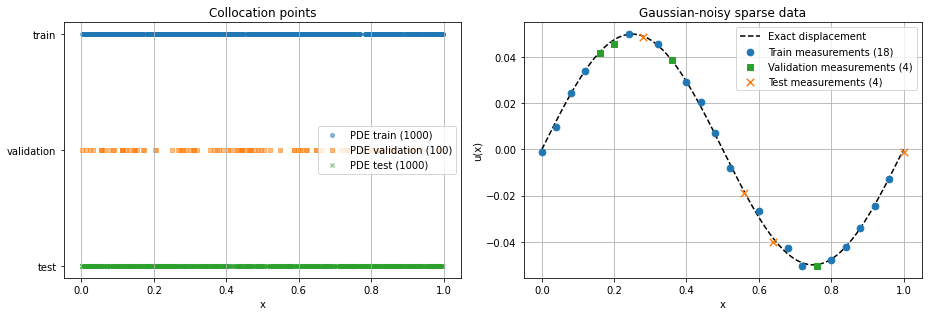

In [87]:
plot_points_and_data()


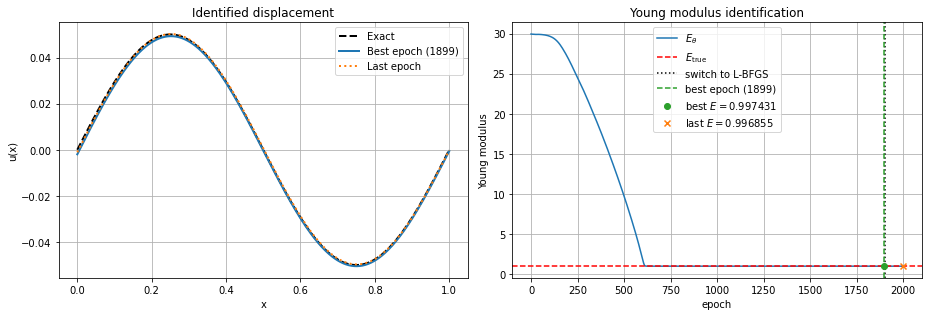

In [88]:
plot_solution_and_modulus()


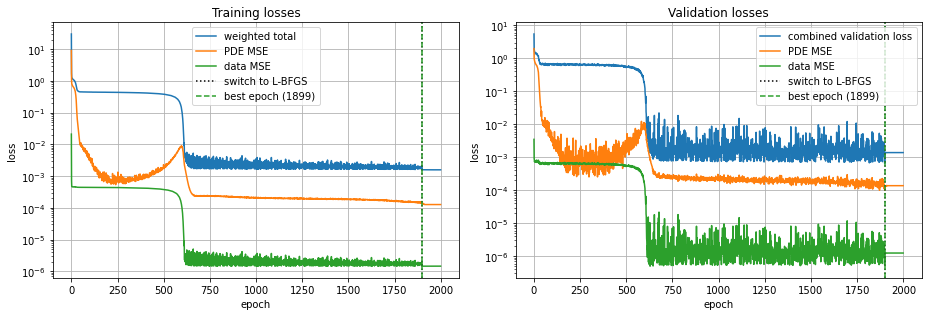

In [89]:
plot_losses()


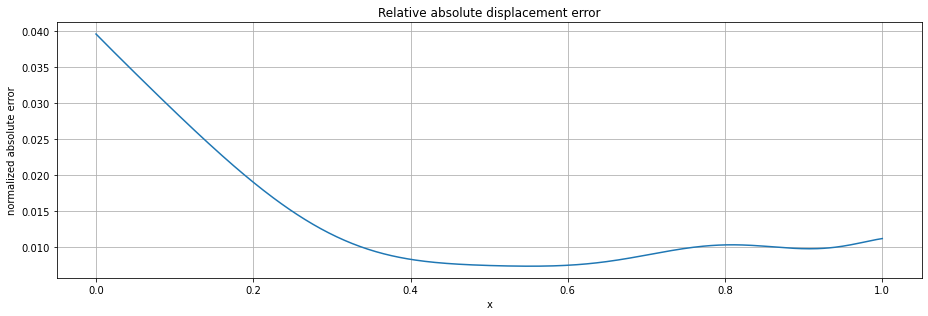

In [90]:
plot_absolute_error()
